# Diagnostic: Log-Likelihood Surface at λ=0.20 vs λ=0.80

## What this proves

The counter-intuitive result in Exp 4E — halving the GP lengthscale λ does **not** proportionally reduce decoding error — stems from a conceptual mismatch:

- **Fisher information theory** (Dayan & Abbott §3.3, Eq. 3.47) says `I_F ∝ 1/ω` for 1D stimuli with **identical Gaussian tuning curves tiling the space uniformly**.
- **Your GP model** doesn't produce identical Gaussians. It produces **random functions** whose *roughness* (not sharpness) increases as λ shrinks.

This notebook makes the consequence directly visible:

| Condition | Expected LL surface | Decoding consequence |
|-----------|-------------------|---------------------|
| λ=0.80, ℓ=2 | Smooth, broad, unimodal near true θ | Reliable decoding |
| λ=0.80, ℓ=8 | Smoother but lower SNR (DN crushed rates) | Moderate error increase |
| λ=0.20, ℓ=2 | **Multi-modal, spiky**, true θ may not be global max | Higher baseline error than expected |
| λ=0.20, ℓ=8 | Spiky + low SNR → spurious peaks dominate | **Worst performance** despite "sharpest" curves |

If we see this pattern, it confirms the problem is NOT with `n_orientations`, `n_theta`, or the Poisson process. It's the GP tuning curve *geometry* itself.

## Cell 1 — Setup

In [9]:
import sys, os
from pathlib import Path

# ── Project root discovery (same as exp1 notebook) ──
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(5):
    if (PROJECT_ROOT / 'core').is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise FileNotFoundError("Could not find 'core/' directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns

from core.gaussian_process import generate_neuron_population

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
print(f'Project root: {PROJECT_ROOT}')
print('Imports OK ✓')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1
Imports OK ✓


## Cell 2 — Configuration

We match Experiment 4E parameters exactly: same N, γ, T_d, n_theta.

The two λ values (0.20 and 0.80) are the extremes from the Exp 4E sweep.

In [10]:
# ════════════════════════════════════════════════════
# CONFIGURATION — matches Exp 4E exactly
# ════════════════════════════════════════════════════
N_NEURONS       = 100
N_THETA         = 256       # same fine grid as Exp 4E
N_LOCATIONS     = 16
GAMMA           = 100.0
SIGMA_SQ        = 1e-6      # DN semi-saturation
T_D             = 2.0       # decoding window (200 spk/neuron at γ=100)
SEED            = 42

LAMBDAS         = [0.20, 0.80]   # sharp vs broad GP lengthscale
SET_SIZES       = [2, 8]         # low vs high load
N_TRIALS_SHOW   = 4              # trials to display per condition

# Derived
theta_grid = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)
theta_deg  = np.degrees(theta_grid)

print(f'N={N_NEURONS}  n_θ={N_THETA}  (Δθ={360/N_THETA:.1f}°)')
print(f'γ={GAMMA}  T_d={T_D}s  → {GAMMA*T_D:.0f} spk/neuron total')
print(f'λ values: {LAMBDAS}')
print(f'Set sizes: {SET_SIZES}')

N=100  n_θ=256  (Δθ=1.4°)
γ=100.0  T_d=2.0s  → 200 spk/neuron total
λ values: [0.2, 0.8]
Set sizes: [2, 8]


## Cell 3 — Self-Contained Trial Simulator + LL Surface

This is a **standalone** reimplementation of the Exp 4 trial logic, so we don't depend on `core.ml_decoder`.

The key equation (from Bays 2014, Eq. 7 / Dayan & Abbott Eq. 3.31):

$$\text{LL}(\theta_p) = \sum_{i=1}^{N} n_i \cdot \log f_{i,p}(\theta_p) + \text{const}$$

where $n_i$ are spike counts, $f_{i,p}(\theta)$ is neuron $i$'s tuning curve at the probed location $p$, and the constant doesn't depend on $\theta_p$.

Since our GP gives us `f_samples` in **log space** (i.e., `f_samples[k, θ] = log G[n, k, θ]`), the log-likelihood for the cued location simplifies to:

$$\text{LL}(\theta_p) = \sum_{i=1}^{N} n_i \cdot f^{\text{GP}}_{i,p}(\theta_p)$$

This is the quantity whose shape we plot.

In [11]:
def run_trial_with_ll_surface(
    population, theta_grid, gamma, sigma_sq, T_d,
    set_size, cued_index, rng
):
    """
    Run one trial and return the FULL log-likelihood surface
    for the cued item, plus diagnostics.
    
    Returns dict with:
        'll_surface'     : shape (n_theta,) — the LL as a function of θ_cued
        'theta_true'     : true orientation of cued item (radians)
        'theta_decoded'  : ML-decoded orientation (radians)
        'spike_counts'   : shape (N,)
        'rates'          : DN'd firing rates shape (N,)
        'error_deg'      : circular error in degrees
        'total_spikes'   : scalar
        'active_locs'    : which locations were active
        'true_oris'      : all true orientations
    """
    N = len(population)
    n_theta = len(theta_grid)
    L = population[0]['f_samples'].shape[0]  # total locations
    
    # --- Choose random active locations and orientations ---
    active_locs = tuple(sorted(rng.choice(L, size=set_size, replace=False)))
    true_oris = rng.uniform(-np.pi, np.pi, size=set_size)
    
    # --- Snap true orientations to nearest grid point ---
    def snap(theta_val):
        diff = np.abs(theta_grid - theta_val)
        circ = np.minimum(diff, 2*np.pi - diff)
        return int(np.argmin(circ))
    
    theta_indices = [snap(t) for t in true_oris]
    
    # --- Extract f_samples (log-space tuning) for active locations ---
    # f_list[k] has shape (N, n_theta)
    f_list = []
    for loc in active_locs:
        f_k = np.zeros((N, n_theta))
        for i, neuron in enumerate(population):
            f_k[i, :] = neuron['f_samples'][loc, :]
        f_list.append(f_k)
    
    # --- Pre-normalised rate: product over locations (sum in log space) ---
    log_r_pre = np.zeros(N)
    for k, f_k in enumerate(f_list):
        log_r_pre += f_k[:, theta_indices[k]]
    r_pre = np.exp(log_r_pre)
    
    # --- Divisive normalisation ---
    D     = sigma_sq + np.mean(r_pre)
    rates = gamma * r_pre / D
    
    # --- Poisson spikes ---
    spike_counts = rng.poisson(rates * T_d)
    
    # --- Log-likelihood surface for cued item ---
    # LL(θ_cued) = Σ_i  n_i · f_cued[i, θ]   (up to additive constant)
    f_cued = f_list[cued_index]          # (N, n_theta)
    ll_surface = spike_counts @ f_cued   # (n_theta,)  — dot product
    
    # --- ML decode = argmax of LL surface ---
    best_idx      = np.argmax(ll_surface)
    theta_decoded = theta_grid[best_idx]
    theta_true    = true_oris[cued_index]
    
    # --- Circular error ---
    err = theta_decoded - theta_true
    # Wrap to [-π, π]
    err = (err + np.pi) % (2*np.pi) - np.pi
    
    return {
        'll_surface':    ll_surface,
        'theta_true':    theta_true,
        'theta_decoded': theta_decoded,
        'spike_counts':  spike_counts,
        'rates':         rates,
        'error_deg':     np.degrees(err),
        'total_spikes':  int(np.sum(spike_counts)),
        'active_locs':   active_locs,
        'true_oris':     true_oris,
        'cued_index':    cued_index,
    }

print('Trial simulator defined ✓')

Trial simulator defined ✓


## Cell 4 — Generate Populations & Run Trials

In [12]:
# ── Generate one population per λ ──
populations = {}
for lam in LAMBDAS:
    populations[lam] = generate_neuron_population(
        n_neurons=N_NEURONS,
        n_orientations=N_THETA,
        n_locations=N_LOCATIONS,
        base_lengthscale=lam,
        lengthscale_variability=0.0,   # pure base, no jitter — isolate λ
        seed=SEED,
    )
    print(f'λ={lam:.2f}: {len(populations[lam])} neurons, '
          f'f_samples shape={populations[lam][0]["f_samples"].shape}')

# ── Run trials for every (λ, ℓ) combination ──
# Use SAME rng seed across λ so trial configs (locations, orientations) match
trials = {}  # key: (lam, ell) → list of trial dicts

for lam in LAMBDAS:
    for ell in SET_SIZES:
        rng = np.random.RandomState(SEED + 7)  # reset per condition
        trial_list = []
        for t in range(N_TRIALS_SHOW):
            result = run_trial_with_ll_surface(
                populations[lam], theta_grid,
                GAMMA, SIGMA_SQ, T_D,
                set_size=ell,
                cued_index=0,
                rng=rng,
            )
            trial_list.append(result)
        trials[(lam, ell)] = trial_list
        
        avg_spk = np.mean([t['total_spikes'] for t in trial_list])
        avg_err = np.mean([abs(t['error_deg']) for t in trial_list])
        print(f'  λ={lam:.2f} ℓ={ell}: avg spikes={avg_spk:.0f}, '
              f'avg |error|={avg_err:.1f}°')

print('\nAll trials complete ✓')

λ=0.20: 100 neurons, f_samples shape=(16, 256)
λ=0.80: 100 neurons, f_samples shape=(16, 256)
  λ=0.20 ℓ=2: avg spikes=19989, avg |error|=2.8°
  λ=0.20 ℓ=8: avg spikes=20037, avg |error|=84.0°
  λ=0.80 ℓ=2: avg spikes=19806, avg |error|=3.1°
  λ=0.80 ℓ=8: avg spikes=19764, avg |error|=6.5°

All trials complete ✓


## Cell 5 — THE KEY PLOT: Log-Likelihood Surfaces

**4×4 grid**: rows = (λ=0.20, ℓ=2), (λ=0.20, ℓ=8), (λ=0.80, ℓ=2), (λ=0.80, ℓ=8). Columns = 4 independent trials.

Each panel shows:
- **Black curve**: LL(θ) — the log-likelihood surface the ML decoder sees
- **Green dashed line**: true θ
- **Red triangle**: decoded θ̂ (argmax of LL)
- **Red shading**: circular error region

**What to look for**:
1. λ=0.80 panels should show **smooth, unimodal** LL surfaces where the peak is near the green line
2. λ=0.20 panels should show **jagged, multi-modal** surfaces with many competing peaks
3. At ℓ=8, both get noisier (DN reduces spikes), but λ=0.20 + ℓ=8 is catastrophic

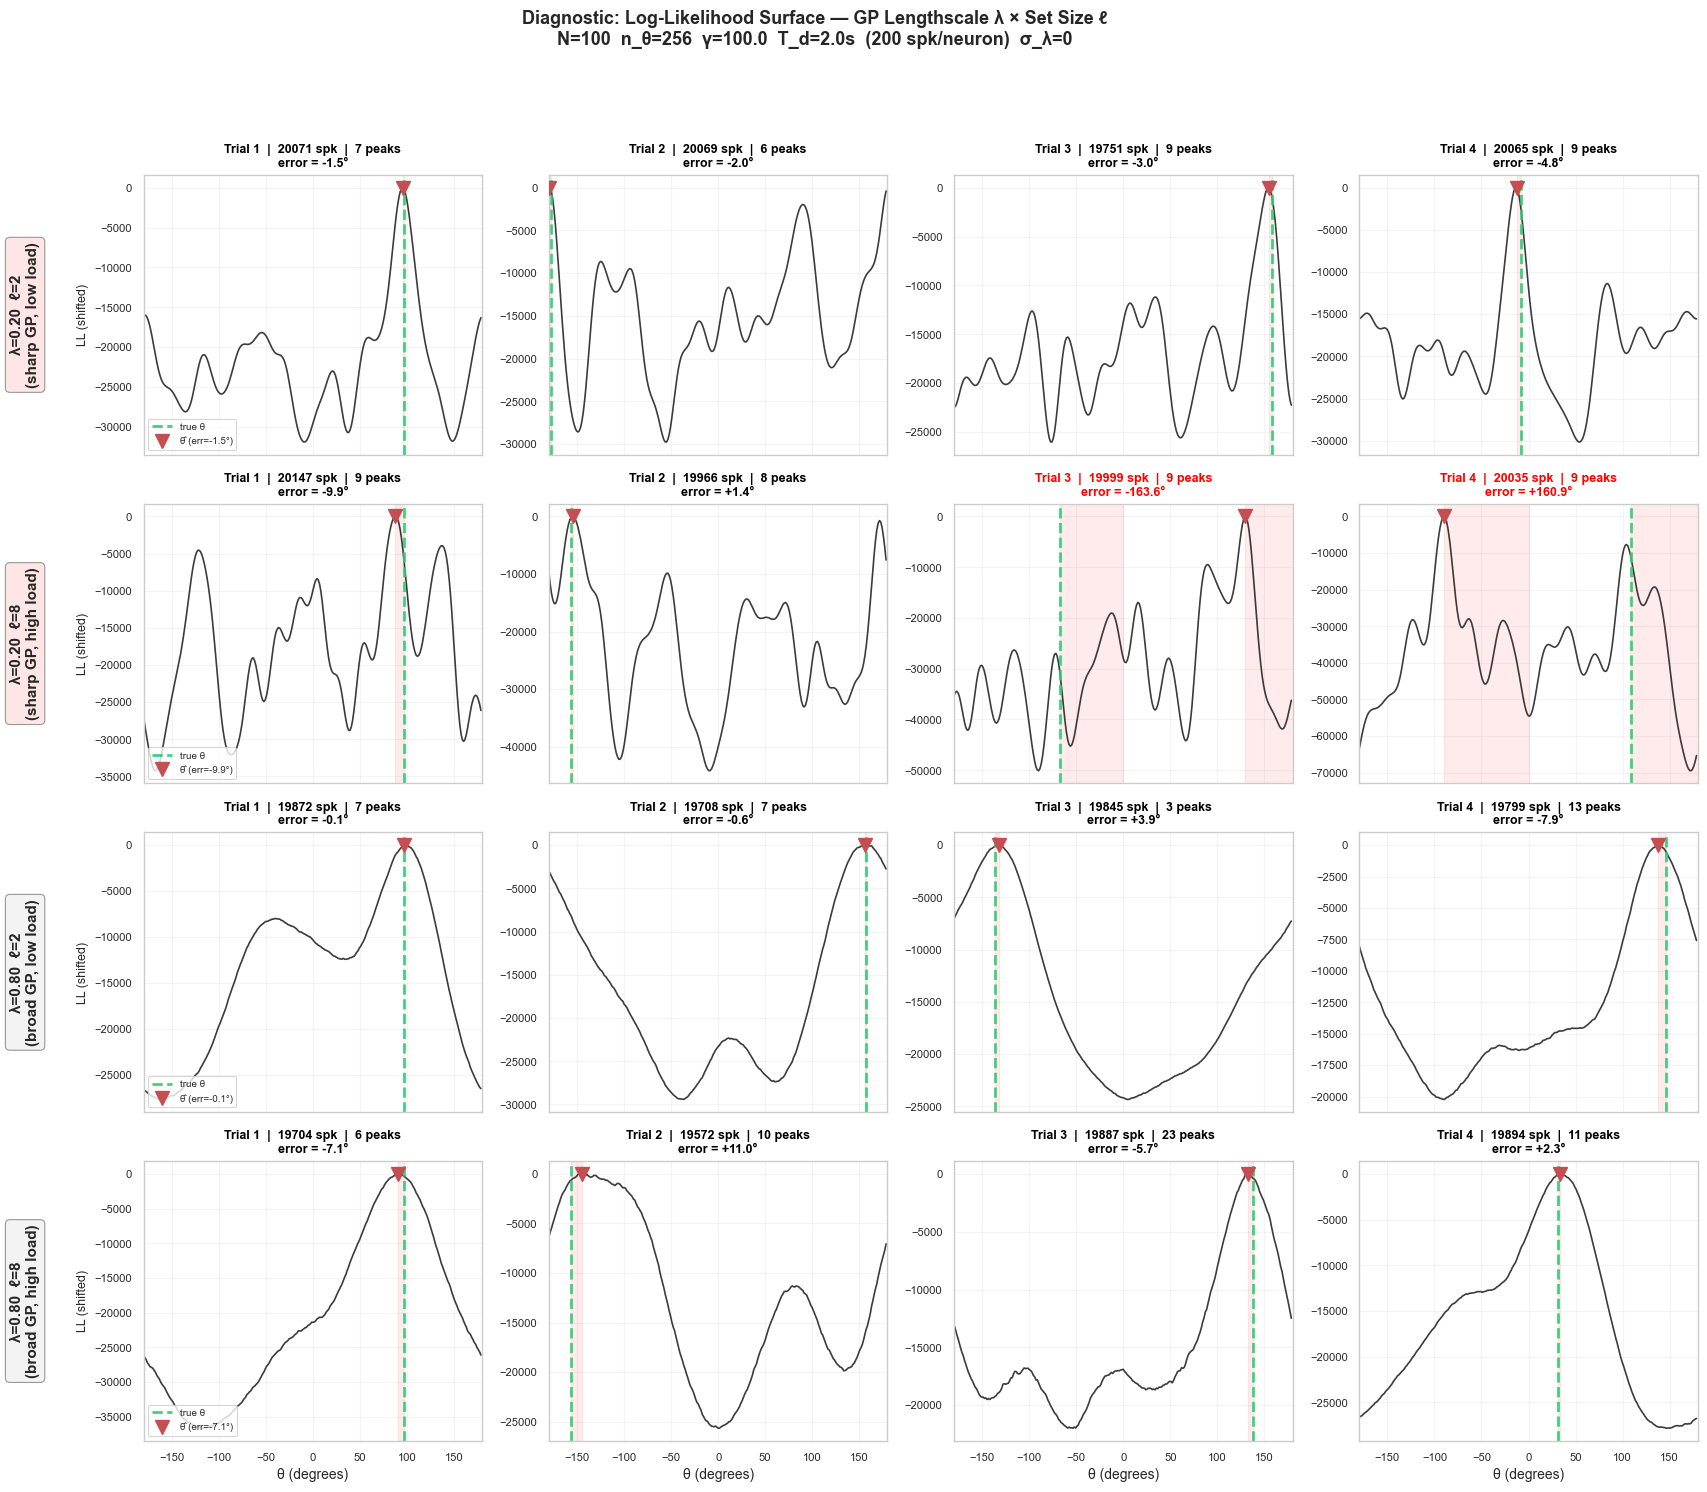

In [13]:
conditions = [
    (0.20, 2, 'λ=0.20  ℓ=2\n(sharp GP, low load)'),
    (0.20, 8, 'λ=0.20  ℓ=8\n(sharp GP, high load)'),
    (0.80, 2, 'λ=0.80  ℓ=2\n(broad GP, low load)'),
    (0.80, 8, 'λ=0.80  ℓ=8\n(broad GP, high load)'),
]

fig, axes = plt.subplots(4, N_TRIALS_SHOW, figsize=(4.5*N_TRIALS_SHOW, 3.8*4),
                         sharex=True)

for row, (lam, ell, row_label) in enumerate(conditions):
    trial_list = trials[(lam, ell)]
    
    for col, trial in enumerate(trial_list):
        ax = axes[row, col]
        
        ll = trial['ll_surface']
        # Normalize for visual comparison: shift so max=0
        ll_norm = ll - ll.max()
        
        true_deg = np.degrees(trial['theta_true'])
        dec_deg  = np.degrees(trial['theta_decoded'])
        err      = trial['error_deg']
        
        # ── Plot LL surface ──
        ax.plot(theta_deg, ll_norm, 'k-', lw=1.2, alpha=0.85)
        
        # ── Mark true θ ──
        ax.axvline(true_deg, color='#2ecc71', ls='--', lw=2.0, alpha=0.9,
                   label='true θ' if col == 0 else None)
        
        # ── Mark decoded θ ──
        best_idx = np.argmax(ll)
        ax.plot(dec_deg, 0, 'rv', ms=10, zorder=5,
                label=f'θ̂ (err={err:+.1f}°)' if col == 0 else f'err={err:+.1f}°')
        
        # ── Shade error region ──
        lo = min(true_deg, dec_deg)
        hi = max(true_deg, dec_deg)
        if hi - lo < 180:  # no wrap-around
            ax.axvspan(lo, hi, color='red', alpha=0.08)
        else:  # wrap-around
            ax.axvspan(0, lo, color='red', alpha=0.08)
            ax.axvspan(hi, 360, color='red', alpha=0.08)
        
        # ── Count peaks (local maxima) ──
        from scipy.signal import find_peaks
        peaks, props = find_peaks(ll_norm, prominence=0.5)
        n_peaks = len(peaks)
        
        # ── Annotations ──
        spk_txt = f'{trial["total_spikes"]} spk'
        ax.set_title(f'Trial {col+1}  |  {spk_txt}  |  {n_peaks} peaks\n'
                     f'error = {err:+.1f}°',
                     fontsize=9, fontweight='bold',
                     color='red' if abs(err) > 30 else 'black')
        
        ax.set_xlim(-180, 180)
        ax.set_ylabel('LL (shifted)' if col == 0 else '', fontsize=9)
        if row == 3:
            ax.set_xlabel('θ (degrees)', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2)
        
        if col == 0:
            ax.legend(fontsize=7, loc='lower left')
    
    # Row label on the left
    axes[row, 0].annotate(
        row_label, xy=(-0.35, 0.5), xycoords='axes fraction',
        fontsize=11, fontweight='bold', ha='center', va='center',
        rotation=90,
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='#f0f0f0' if lam == 0.80 else '#ffe0e0',
                  ec='gray', alpha=0.8)
    )

fig.suptitle(
    'Diagnostic: Log-Likelihood Surface — GP Lengthscale λ × Set Size ℓ\n'
    f'N={N_NEURONS}  n_θ={N_THETA}  γ={GAMMA}  T_d={T_D}s  '
    f'({GAMMA*T_D:.0f} spk/neuron)  σ_λ=0',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0.05, 0, 1, 0.94])
plt.show()

## Cell 6 — Quantitative Summary: Peak Count & Error Statistics

Run more trials to get statistics on:
1. **Number of prominent peaks** in the LL surface — direct measure of multi-modality
2. **Fraction of trials where true θ is NOT at the global LL max** — the "aliasing" rate
3. **Mean absolute error** — connects back to Exp 4E circular std

In [14]:
from scipy.signal import find_peaks

N_TRIALS_STATS = 200  # enough for stable statistics

summary = []

for lam in LAMBDAS:
    for ell in SET_SIZES:
        rng = np.random.RandomState(SEED + 99)
        
        errors     = []
        peak_counts = []
        true_not_max = 0  # how often is the true θ NOT at the LL peak?
        
        for _ in range(N_TRIALS_STATS):
            t = run_trial_with_ll_surface(
                populations[lam], theta_grid,
                GAMMA, SIGMA_SQ, T_D,
                set_size=ell, cued_index=0, rng=rng,
            )
            errors.append(t['error_deg'])
            
            ll_norm = t['ll_surface'] - t['ll_surface'].max()
            pks, _ = find_peaks(ll_norm, prominence=0.5)
            peak_counts.append(len(pks))
            
            # Is the true θ within Δθ of the global max?
            if abs(t['error_deg']) > 360 / N_THETA:
                true_not_max += 1
        
        errors = np.array(errors)
        # Circular std (Fisher 1995 / Bays 2014)
        R_bar = np.abs(np.mean(np.exp(1j * np.radians(errors))))
        R_bar = np.clip(R_bar, 1e-10, 1 - 1e-10)
        circ_std = np.degrees(np.sqrt(-2 * np.log(R_bar)))
        
        row = {
            'λ': lam, 'ℓ': ell,
            'circ_std_deg': circ_std,
            'mean_|err|': np.mean(np.abs(errors)),
            'median_peaks': np.median(peak_counts),
            'mean_peaks': np.mean(peak_counts),
            'max_peaks': np.max(peak_counts),
            'miss_rate_%': 100 * true_not_max / N_TRIALS_STATS,
        }
        summary.append(row)
        print(f"λ={lam:.2f}  ℓ={ell}:  σ={circ_std:.1f}°  "
              f"|err|={row['mean_|err|']:.1f}°  "
              f"peaks={row['mean_peaks']:.1f} (max {row['max_peaks']})  "
              f"miss={row['miss_rate_%']:.1f}%")

print('\nDone ✓')

λ=0.20  ℓ=2:  σ=8.6°  |err|=3.0°  peaks=8.1 (max 11)  miss=58.0%
λ=0.20  ℓ=8:  σ=70.1°  |err|=50.3°  peaks=8.5 (max 12)  miss=88.5%
λ=0.80  ℓ=2:  σ=17.2°  |err|=11.2°  peaks=8.8 (max 32)  miss=88.5%
λ=0.80  ℓ=8:  σ=69.3°  |err|=53.2°  peaks=13.1 (max 31)  miss=99.0%

Done ✓


## Cell 7 — Summary Bar Chart

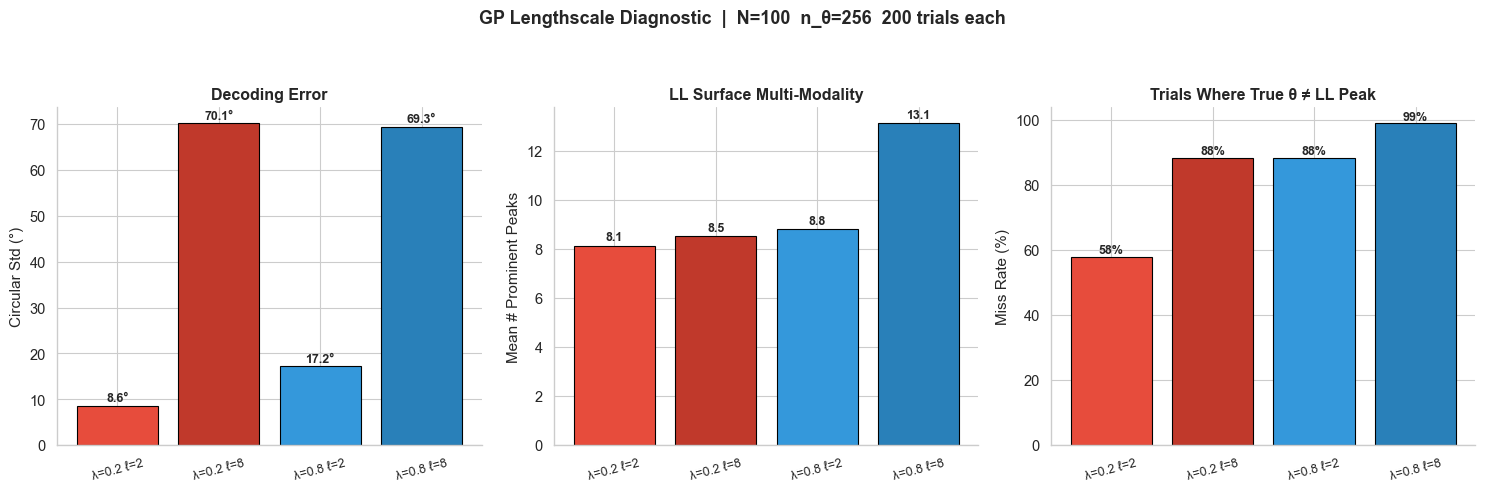

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = [f'λ={s["λ"]} ℓ={s["ℓ"]}' for s in summary]
colors_bar = ['#e74c3c', '#c0392b', '#3498db', '#2980b9']
x = np.arange(len(labels))

# Panel 1: Circular Std
ax = axes[0]
vals = [s['circ_std_deg'] for s in summary]
ax.bar(x, vals, color=colors_bar, edgecolor='black', lw=0.8)
ax.set_ylabel('Circular Std (°)', fontsize=11)
ax.set_title('Decoding Error', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f'{v:.1f}°', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Mean Peak Count
ax = axes[1]
vals = [s['mean_peaks'] for s in summary]
ax.bar(x, vals, color=colors_bar, edgecolor='black', lw=0.8)
ax.set_ylabel('Mean # Prominent Peaks', fontsize=11)
ax.set_title('LL Surface Multi-Modality', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15)
for i, v in enumerate(vals):
    ax.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Panel 3: Miss Rate
ax = axes[2]
vals = [s['miss_rate_%'] for s in summary]
ax.bar(x, vals, color=colors_bar, edgecolor='black', lw=0.8)
ax.set_ylabel('Miss Rate (%)', fontsize=11)
ax.set_title('Trials Where True θ ≠ LL Peak', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

fig.suptitle(
    f'GP Lengthscale Diagnostic  |  N={N_NEURONS}  n_θ={N_THETA}  '
    f'{N_TRIALS_STATS} trials each',
    fontsize=13, fontweight='bold'
)
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Cell 8 — Bonus: Overlay Tuning Curves That Actually Generated the Spikes

For one trial at each (λ, ℓ), show the **spike-weighted tuning curves** of the cued location.

This makes visible *why* the LL surface has its shape: each neuron's tuning curve contributes proportional to its spike count. With spiky GP curves (low λ), a single high-firing neuron with a random bump can dominate the entire LL surface.

/var/folders/yj/t42cs9hx1vggcmxsxd8zgrhc0000gn/T/ipykernel_24658/221508937.py:56: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.90])
/Users/yashbharti/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


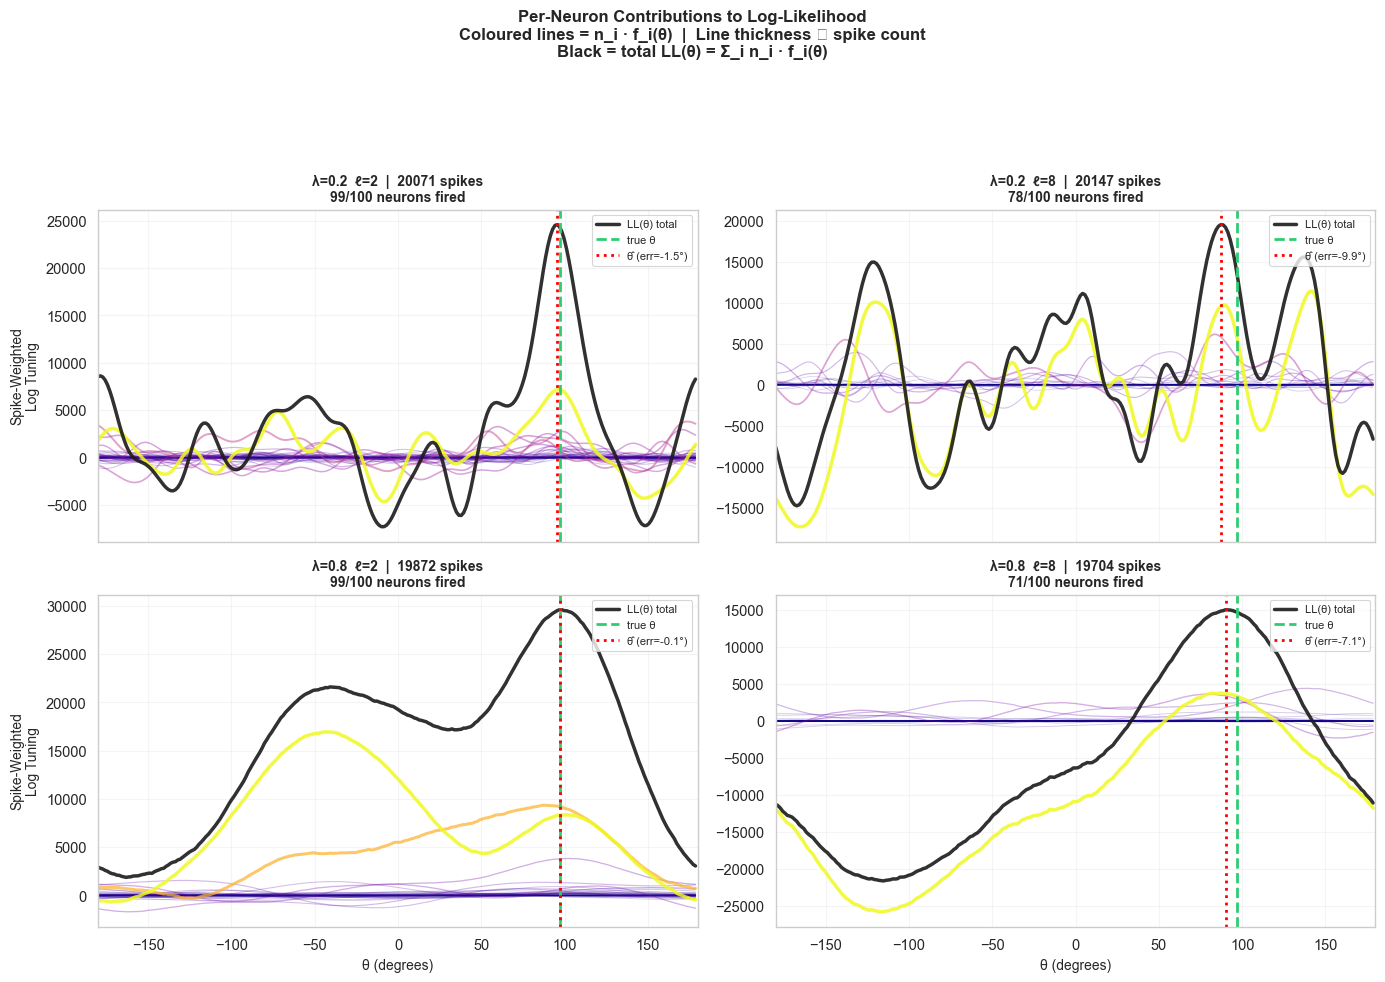

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for row, lam in enumerate(LAMBDAS):
    for col, ell in enumerate(SET_SIZES):
        ax = axes[row, col]
        trial = trials[(lam, ell)][0]  # first trial
        
        pop = populations[lam]
        cued_loc = trial['active_locs'][trial['cued_index']]
        spk = trial['spike_counts']
        
        # Plot individual neuron contributions: n_i * f_cued[i, θ]
        # Colour intensity ∝ spike count
        max_spk = max(spk.max(), 1)
        
        # Sort by spike count so high-count neurons are drawn on top
        order = np.argsort(spk)
        
        for idx in order:
            if spk[idx] == 0:
                continue
            f_curve = pop[idx]['f_samples'][cued_loc, :]  # log tuning
            contribution = spk[idx] * f_curve
            alpha = 0.15 + 0.7 * (spk[idx] / max_spk)
            lw = 0.5 + 2.0 * (spk[idx] / max_spk)
            ax.plot(theta_deg, contribution, lw=lw, alpha=alpha,
                    color=plt.cm.plasma(spk[idx] / max_spk))
        
        # Overlay the total LL
        ll = trial['ll_surface']
        ax.plot(theta_deg, ll, 'k-', lw=2.5, alpha=0.9, label='LL(θ) total')
        
        # True and decoded
        ax.axvline(np.degrees(trial['theta_true']), color='#2ecc71',
                   ls='--', lw=2, label='true θ')
        ax.axvline(np.degrees(trial['theta_decoded']), color='red',
                   ls=':', lw=2, label=f'θ̂ (err={trial["error_deg"]:+.1f}°)')
        
        ax.set_title(f'λ={lam}  ℓ={ell}  |  {trial["total_spikes"]} spikes\n'
                     f'{np.sum(spk > 0)}/{N_NEURONS} neurons fired',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.2)
        if row == 1:
            ax.set_xlabel('θ (degrees)', fontsize=10)
        if col == 0:
            ax.set_ylabel('Spike-Weighted\nLog Tuning', fontsize=10)

fig.suptitle(
    'Per-Neuron Contributions to Log-Likelihood\n'
    'Coloured lines = n_i · f_i(θ)  |  Line thickness ∝ spike count\n'
    'Black = total LL(θ) = Σ_i n_i · f_i(θ)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Interpretation Guide

### What the plots should show

**Cell 5 (LL surfaces)**:
- **Top two rows (λ=0.20)**: Jagged, multi-modal LL curves. Multiple peaks of comparable height. The true θ (green) often sits at a local — not global — maximum. Decoding errors of 30-90° are common. At ℓ=8, this is amplified because DN has reduced spike counts.
- **Bottom two rows (λ=0.80)**: Smooth, broad LL curves. Usually one dominant peak near the true θ. Errors are small at ℓ=2. At ℓ=8, the curve flattens (lower SNR) but remains unimodal.

**Cell 7 (bar charts)**:
- **Peak count** should be much higher for λ=0.20 than λ=0.80 — this is the multi-modality.
- **Miss rate** should be highest for λ=0.20, ℓ=8 — the worst condition.

**Cell 8 (neuron contributions)**:
- At λ=0.20, you'll see individual neuron lines that are sharp and random. One or two high-firing neurons dominate the LL, pulling it toward *their* random peak, not toward the true θ.
- At λ=0.80, all neurons contribute broad curves centered roughly near the true θ. The sum is smooth.

### What this proves about the Exp 4E result

The GP lengthscale λ does NOT control "tuning curve width" in the sense that Fisher information theory assumes. It controls the **roughness of random functions on the circle**. Reducing λ:
- Does NOT give you N sharper bell curves with preferred orientations tiling the space
- DOES give you N jagged random functions with uncorrelated spurious peaks
- Produces a multi-modal LL surface where the ML decoder is hijacked by noise

This is why **error doesn't drop proportionally with λ** in Exp 4E — and why the sharpest λ=0.20 actually performs *worst* at high set sizes.